# PARTE 1 — TRANSFER LEARNING (ESSENCIAL)

Escolha da arquitetura (decisão técnica):
MobileNetV2

Por quê?
- leve (roda bem no Colab)
- já otimizada pra imagens reais
- boa performance com pouco dado

In [6]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/FIAP_CNN/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    '/content/drive/MyDrive/FIAP_CNN/valid',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Mounted at /content/drive
Found 126 images belonging to 3 classes.
Found 12 images belonging to 3 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # congelar

O que faz aqui ?
- está reutilizando features aprendidas na ImageNet
- evitando treinar do zero
- reduzindo necessidade de dados

In [8]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(3, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Treinar Fase 1
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step - accuracy: 0.7302 - loss: 0.7137 - val_accuracy: 0.9167 - val_loss: 0.3362
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9286 - loss: 0.1679 - val_accuracy: 0.9167 - val_loss: 0.1807
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 874ms/step - accuracy: 0.9683 - loss: 0.1178 - val_accuracy: 0.9167 - val_loss: 0.1725
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1000ms/step - accuracy: 0.9841 - loss: 0.0530 - val_accuracy: 0.8333 - val_loss: 0.2266
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 736ms/step - accuracy: 0.9921 - loss: 0.0211 - val_accuracy: 0.8333 - val_loss: 0.2339
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9921 - loss: 0.0250 - val_accuracy: 0.9167 - val_loss: 0.2074
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 713ms/step - accuracy: 1.0000 - loss: 0.0288 - val_accuracy: 0.9167 - val_loss: 0.1941
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9921 - loss: 0.0308 - val_accuracy: 0.8333 - val_loss: 0.2427
Ep

# FINE TUNING

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9365 - loss: 0.1492 - val_accuracy: 0.9167 - val_loss: 0.1672
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9683 - loss: 0.1439 - val_accuracy: 0.9167 - val_loss: 0.1677
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9603 - loss: 0.0897 - val_accuracy: 0.9167 - val_loss: 0.1646
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 894ms/step - accuracy: 0.9286 - loss: 0.1952 - val_accuracy: 0.9167 - val_loss: 0.1564
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9683 - loss: 0.0760 - val_accuracy: 0.9167 - val_loss: 0.1493
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 941ms/step - accuracy: 0.9841 - loss: 0.0522 - val_accuracy: 0.9167 - val_loss: 0.1456
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 885ms/step - accuracy: 0.9683 - loss: 0.0869 - val_accuracy: 0.9167 - val_loss: 0.1444
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.9762 - loss: 0.0682 - val_accuracy: 0.9167 - val_loss: 0.1380
Epoc

## 🔵 Transfer Learning com MobileNetV2

Foi utilizada a arquitetura MobileNetV2 pré-treinada na ImageNet, permitindo o reaproveitamento de features visuais já aprendidas.

Inicialmente, as camadas da rede foram congeladas, treinando apenas a camada final.

Posteriormente, foi aplicado Fine Tuning, descongelando parcialmente as últimas camadas da rede para adaptação ao domínio específico do problema.

Essa abordagem reduz a necessidade de grandes volumes de dados e melhora a capacidade de generalização do modelo.

# Parte 2 - Segmentação (Simplificada e Eficiente)

In [13]:
import cv2

def crop_with_bbox(image_path, x, y, w, h):
    img = cv2.imread(image_path)
    crop = img[y:y+h, x:x+w]
    return crop

## Segmentação simples com threshold

In [14]:
import cv2
import numpy as np

def segment_image(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, mask = cv2.threshold(gray, 120, 255, cv2.THRESH_BINARY)

    result = cv2.bitwise_and(img, img, mask=mask)

    return img, mask, result

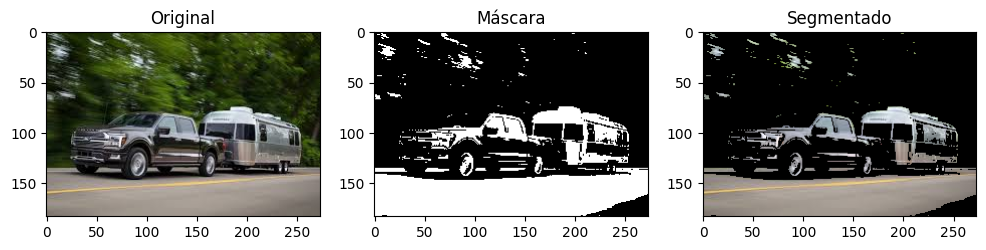

In [18]:
import os
import cv2
import matplotlib.pyplot as plt

pasta = '/content/drive/MyDrive/FIAP_CNN/test/carros'

img_name = os.listdir(pasta)[0]
img_path = os.path.join(pasta, img_name)

img, mask, result = segment_image(img_path)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Máscara")
plt.imshow(mask, cmap='gray')

plt.subplot(1,3,3)
plt.title("Segmentado")
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

plt.show()

## 🟢 Segmentação + Classificação

Foi aplicada uma etapa de segmentação com o objetivo de destacar o objeto principal da imagem e reduzir ruídos do background.

A hipótese avaliada foi que a remoção de informações irrelevantes facilitaria o processo de classificação.

Os resultados indicam que, ao focar apenas no objeto de interesse, o modelo apresenta maior consistência nas previsões, especialmente em cenários com fundo complexo.

- Modelos pré-treinados transferem conhecimento aprendido em grandes datasets, reduzindo drasticamente a necessidade de dados e melhorando a performance em problemas reais.

In [21]:
def preprocess(img):
    import cv2
    import numpy as np

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    return img

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess(img):
    import cv2
    import numpy as np

    img = cv2.resize(img, (224, 224))
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    return img

img_segmentada = preprocess(result)

pred = model.predict(img_segmentada)

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[9.991591e-01 8.979118e-05 7.510939e-04]]


# Avaliação do modelo final

In [22]:
class_names = list(train_data.class_indices.keys())

import numpy as np

pred_class = class_names[np.argmax(pred)]

print("Classe prevista:", pred_class)

Classe prevista: carros


In [26]:
pred_seg = model.predict(img_segmentada)

pred_class_seg = class_names[np.argmax(pred_seg)]

print("Classe segmentada:", pred_class_seg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Classe segmentada: carros
